# Testing Multi-Armed Bandit (MAB) Environment

This notebook demonstrates the key features of the Multi-Armed Bandit environment. We'll explore:

1. Basic functionality without confounding
2. Effects of confounding on observational vs interventional data
3. Different behavioral policies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs import MABPCH
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                      message="Overriding environment .* already in registry")

In [2]:
# Parameters
N_EPISODES = 1000
ARMS_PROBS = [0.4, 0.3]  # Reward probabilities for arms 0 and 1

In [3]:
def run_observational(env, n_episodes):
    """Run episodes under observational policy"""
    actions = []
    rewards = []
    print("Running Observational...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")

        env.reset()
            
        _, reward, term, _, info = env.see()
        actions.append(info['natural_action'])
        rewards.append(reward)
        
    print("Finished observational run.")
    return np.array(actions), np.array(rewards)

def run_interventional(env, n_episodes, action):
    """Run episodes with fixed intervention"""
    rewards = []
    print(f"Running Interventional (do={action})...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")

        env.reset()
        
        _, reward, term, _, _ = env.do(action)
        rewards.append(reward)
        
    print("Finished interventional run.")
    return np.array(rewards)

## Test 1: No Confounding

First, let's test without confounding. This should show clear differences in reward probabilities between arms.

In [4]:
# Create environment without confounding
env = MABPCH(confounding_strength=0.0, arms_probs=ARMS_PROBS)

# Run observational policy
obs_actions, obs_rewards = run_observational(env, N_EPISODES)

def policy_0():
    return 0

def policy_1():
    return 1

# Run interventional policy for each arm
int_rewards_0 = run_interventional(env, N_EPISODES, policy_0)
int_rewards_1 = run_interventional(env, N_EPISODES, policy_1)

print("\nResults without confounding:")
print(f"Observational average reward: {obs_rewards.mean():.3f}")
print(f"Observational arm 0 reward: {obs_rewards[obs_actions == 0].mean():.3f}")
print(f"Observational arm 1 reward: {obs_rewards[obs_actions == 1].mean():.3f}")
print(f"Interventional arm 0 reward: {int_rewards_0.mean():.3f}")
print(f"Interventional arm 1 reward: {int_rewards_1.mean():.3f}")

Running Observational...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished observational run.
Running Interventional (do=<function policy_0 at 0x106abe840>)...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished interventional run.
Running Interventional (do=<function policy_1 at 0x106abe980>)...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished interventional run.

Results without confounding:
Observational average reward: 0.317
Observational arm 0 reward: 0.359
Observational arm 1 reward: 0.308
Interventional arm 0 reward: 0.424
Interventional 

## Test 2: With Confounding

Now let's test with confounding. We should see differences between observational and interventional distributions.

Running Observational...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished observational run.
Running Interventional (do=<function policy_0 at 0x106abe840>)...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished interventional run.
Running Interventional (do=<function policy_1 at 0x106abe980>)...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished interventional run.

Results with confounding:
Observational average reward: 0.208
Observational arm 0 reward: 0.296
Observational arm 1 reward: 0.198
Interventional arm 0 reward: 0.330
Interventional arm

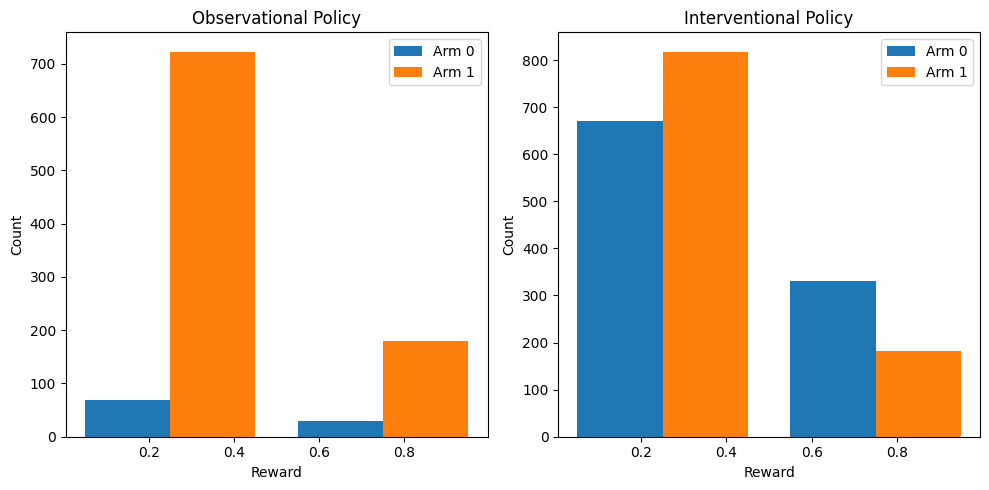

In [6]:
# Create environment with confounding
env = MABPCH(confounding_strength=0.2, arms_probs=ARMS_PROBS)

# Run observational policy
obs_actions, obs_rewards = run_observational(env, N_EPISODES)

# Run interventional policy for each arm
int_rewards_0 = run_interventional(env, N_EPISODES, policy_0)
int_rewards_1 = run_interventional(env, N_EPISODES, policy_1)

print("\nResults with confounding:")
print(f"Observational average reward: {obs_rewards.mean():.3f}")
print(f"Observational arm 0 reward: {obs_rewards[obs_actions == 0].mean():.3f}")
print(f"Observational arm 1 reward: {obs_rewards[obs_actions == 1].mean():.3f}")
print(f"Interventional arm 0 reward: {int_rewards_0.mean():.3f}")
print(f"Interventional arm 1 reward: {int_rewards_1.mean():.3f}")

# Plot distributions
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Observational Policy')
plt.hist([obs_rewards[obs_actions == 0], obs_rewards[obs_actions == 1]], 
         label=['Arm 0', 'Arm 1'], bins=2)
plt.xlabel('Reward')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Interventional Policy')
plt.hist([int_rewards_0, int_rewards_1], 
         label=['Arm 0', 'Arm 1'], bins=2)
plt.xlabel('Reward')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

## Test 3: Custom Policy

Let's test with a custom behavioral policy that always chooses arm 0.

Running Observational...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished observational run.

Results with custom policy (always select arm 0):
Average reward: 0.208
Action distribution: [0.109 0.891]


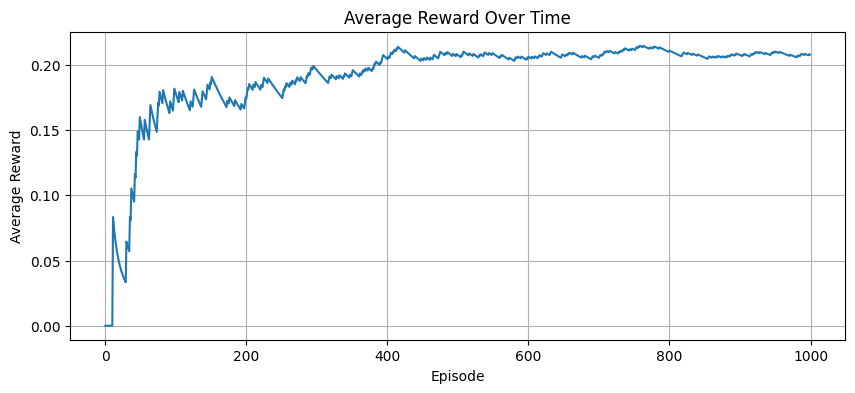

In [7]:
# Create environment
env = MABPCH(confounding_strength=0.2, arms_probs=ARMS_PROBS)

# Custom policy that always selects arm 0
def custom_policy():
    return 0

# Run observational policy with custom behavior
obs_actions, obs_rewards = run_observational(env, N_EPISODES)

print("\nResults with custom policy (always select arm 0):")
print(f"Average reward: {obs_rewards.mean():.3f}")
print(f"Action distribution: {np.bincount(obs_actions) / len(obs_actions)}")

# Plot rewards over time
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(obs_rewards) / np.arange(1, len(obs_rewards) + 1))
plt.title('Average Reward Over Time')
plt.xlabel('Episode')
plt.ylabel('Average Reward')
plt.grid(True)
plt.show()